# Data Preparation

**Import Libraries**

In [1]:
#import libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import auc,roc_auc_score,roc_curve
from sklearn.metrics import precision_recall_curve
#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import _tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.tree import plot_tree





**Obtain data file path**

In [ ]:
from google.colab import files 
uploaded = files.upload()

Saving diabetes_data_upload.csv to diabetes_data_upload.csv


**Load data**

In [ ]:
data = 'diabetes_data_upload.csv'
diab_data=pd.read_csv('diabetes_data_upload.csv')

**View data**

**Preview the first five rows of the dataset**

In [ ]:
diab_data.head()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


**Preview the last five rows of the dataset**

In [ ]:
diab_data.tail()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
515,39,Female,Yes,Yes,Yes,No,Yes,No,No,Yes,No,Yes,Yes,No,No,No,Positive
516,48,Female,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,No,No,Positive
517,58,Female,Yes,Yes,Yes,Yes,Yes,No,Yes,No,No,No,Yes,Yes,No,Yes,Positive
518,32,Female,No,No,No,Yes,No,No,Yes,Yes,No,Yes,No,No,Yes,No,Negative
519,42,Male,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Negative


# Data Exploration

Preview the column names of the dataset

In [ ]:
diab_data.columns

Index(['Age', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss',
       'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring',
       'Itching', 'Irritability', 'delayed healing', 'partial paresis',
       'muscle stiffness', 'Alopecia', 'Obesity', 'class'],
      dtype='object')

In [ ]:
diab_data.shape #check the number of rows and columns in the dataset

(520, 17)

**Statistical information of the dataset**

In [ ]:
diab_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 520 non-null    int64 
 1   Gender              520 non-null    object
 2   Polyuria            520 non-null    object
 3   Polydipsia          520 non-null    object
 4   sudden weight loss  520 non-null    object
 5   weakness            520 non-null    object
 6   Polyphagia          520 non-null    object
 7   Genital thrush      520 non-null    object
 8   visual blurring     520 non-null    object
 9   Itching             520 non-null    object
 10  Irritability        520 non-null    object
 11  delayed healing     520 non-null    object
 12  partial paresis     520 non-null    object
 13  muscle stiffness    520 non-null    object
 14  Alopecia            520 non-null    object
 15  Obesity             520 non-null    object
 16  class               520 no

**Descriptive analysis of the dataset**

In [ ]:
diab_data.describe(include='all')

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
count,520.000000,520,520,520,520,520,520,520,520,520,520,520,520,520,520,520,520
unique,NaN,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
top,NaN,Male,No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,Positive
freq,NaN,328,262,287,303,305,283,404,287,267,394,281,296,325,341,432,320
mean,48.028846,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,12.151466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,16.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,39.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,47.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,57.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Data Cleaning

**Check null values/missing data**

In [ ]:
diab_data.isnull().sum()

Age                   0
Gender                0
Polyuria              0
Polydipsia            0
sudden weight loss    0
weakness              0
Polyphagia            0
Genital thrush        0
visual blurring       0
Itching               0
Irritability          0
delayed healing       0
partial paresis       0
muscle stiffness      0
Alopecia              0
Obesity               0
class                 0
dtype: int64

**Check for duplicates**

In [ ]:
diab_data.duplicated().sum()

269

**Preview the first five duplicated rows in the dataset**

In [ ]:
diab_data[diab_data.duplicated()].head()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
84,35,Female,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,No,Yes,Yes,Yes,No,No,Positive
159,38,Female,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Positive
160,28,Female,No,No,No,No,No,No,Yes,No,No,No,Yes,Yes,No,No,Positive
161,68,Female,Yes,Yes,No,Yes,Yes,No,Yes,Yes,No,Yes,Yes,No,No,No,Positive
162,35,Female,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Positive


# Feature Engineering


In [ ]:
diab_data.head() #preview the changes made to the column headers

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


**Create a copy of the dataset and new feature 'age group'**

In [ ]:
diab_data1 = diab_data.copy()

def age(i):
    for x in range(10,100,10):
        if i<x:
            m = f'{x-10}-{x}'
            return m
            break

diab_data1['age_group'] = diab_data['Age'].apply(lambda x:age(x))
diab_data1.head()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class,age_group
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive,40-50
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive,50-60
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive,40-50
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive,40-50
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive,60-70


In [ ]:
label_encoder = preprocessing.LabelEncoder()

for column in diab_data.columns[1:]:
    diab_data[column] =  label_encoder.fit_transform(diab_data[column])
    
diab_data.head()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


In [ ]:
neg = len(diab_data[diab_data['class']==0])
pos = len(diab_data[diab_data['class']==1])

pct_of_neg = neg/(neg+pos)
print("percentage of negative class is", pct_of_neg*100)
pct_of_pos = pos/(neg+pos)
print("percentage of positive class is", pct_of_pos*100)

percentage of negative class is 38.46153846153847
percentage of positive class is 61.53846153846154


# Training the Data

We need to split  our dataset before we train it. X will contain all independent while y will contain dependent variables ('status')


In [ ]:
X = diab_data.drop('class', axis =1)
y = diab_data['class']

<span style= "font-size:20px; font-weight:bold;">Data Normalization</span>

In [ ]:
X_norm=(X-X.mean())/X.std()

X_norm = pd.DataFrame(X_norm)
X_norm

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity
0,-0.660731,0.764356,-0.991382,1.108779,-0.845455,0.838786,-0.914246,-0.535328,-0.900159,1.026307,-0.564962,1.083269,-0.869081,1.289753,1.378900,2.213515
1,0.820572,0.764356,-0.991382,-0.900159,-0.845455,0.838786,-0.914246,-0.535328,1.108779,-0.972493,-0.564962,-0.921357,1.148428,-0.773852,1.378900,-0.450901
2,-0.578436,0.764356,1.006753,-0.900159,-0.845455,0.838786,1.091694,-0.535328,-0.900159,1.026307,-0.564962,1.083269,-0.869081,1.289753,1.378900,-0.450901
3,-0.249258,0.764356,-0.991382,-0.900159,1.180520,0.838786,1.091694,1.864420,-0.900159,1.026307,-0.564962,1.083269,-0.869081,-0.773852,-0.723821,-0.450901
4,0.985161,0.764356,1.006753,1.108779,1.180520,0.838786,1.091694,-0.535328,1.108779,1.026307,1.766627,1.083269,1.148428,1.289753,1.378900,2.213515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,-0.743025,-1.305775,1.006753,1.108779,1.180520,-1.189906,1.091694,-0.535328,-0.900159,1.026307,-0.564962,1.083269,1.148428,-0.773852,-0.723821,-0.450901
516,-0.002374,-1.305775,1.006753,1.108779,1.180520,0.838786,1.091694,-0.535328,-0.900159,1.026307,1.766627,1.083269,1.148428,-0.773852,-0.723821,-0.450901
517,0.820572,-1.305775,1.006753,1.108779,1.180520,0.838786,1.091694,-0.535328,1.108779,-0.972493,-0.564962,-0.921357,1.148428,1.289753,-0.723821,2.213515
518,-1.319087,-1.305775,-0.991382,-0.900159,-0.845455,0.838786,-0.914246,-0.535328,1.108779,1.026307,-0.564962,1.083269,-0.869081,-0.773852,1.378900,-0.450901


<span style= "font-size:18px; font-weight:bold;">Train and Test Split</span>

After sucessfully splitting the dataset into independent and dependent variables, we need to further split it into training and testing set.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_norm,y, test_size = 0.2, stratify=y, random_state = 1)

In [ ]:
print('The shape of X_train', X_train.shape)
print('The shape of X_test', X_test.shape)
print('The shape of y_train', y_train.shape)
print('The shape of y_test', y_test.shape)

The shape of X_train (416, 16)
The shape of X_test (104, 16)
The shape of y_train (416,)
The shape of y_test (104,)


In [ ]:
y_train.value_counts() # distribution of target variable in training set

1    256
0    160
Name: class, dtype: int64

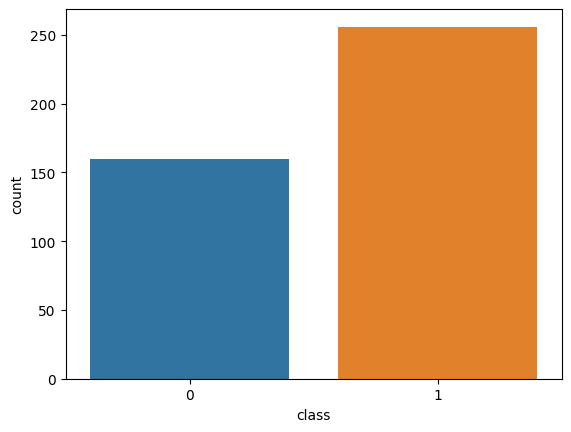

In [ ]:
sns.countplot(x=y_train); 

In [ ]:
y_test.value_counts() # distribution of target variable in test set

1    64
0    40
Name: class, dtype: int64

<span style= "font-size:18px; font-weight:bold;">Baseline Score</span>

In [ ]:
acc_baseline = y_train.value_counts(normalize=True).max()
print('Baseline Accuracy:', round(acc_baseline,4))

Baseline Accuracy: 0.6154


# **Building the Models**

<span style= "font-size:20px; font-weight:bold;"> Logistic Regression</span>

In [ ]:
lr = LogisticRegression()
lr

LogisticRegression()

In [ ]:
lr.fit(X_train, y_train)
print(f'model score on training data: {lr.score(X_train, y_train)}')
print(f'model score on testing data: {lr.score(X_test, y_test)}')

model score on training data: 0.9230769230769231
model score on testing data: 0.9615384615384616


In [ ]:
print(len(X_train.columns.tolist()))
len(lr.coef_[0])

16


16

<span style= "font-size:18px; font-weight:bold;">Feature Importance for Logistic Regression</span>

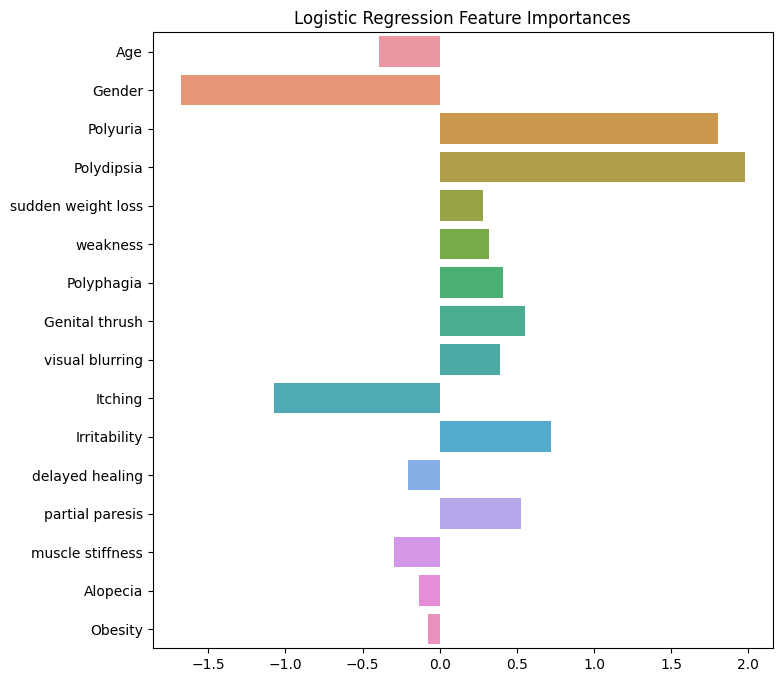

In [ ]:
plt.figure(figsize = (8,8))
sns.barplot(x = lr.coef_[0], y = X_train.columns.tolist())
plt.title('Logistic Regression Feature Importances');

<span style= "font-size:18px; font-weight:bold;">Permutation Importance for Logistic Regression</span>

<span style= "font-size:18px; font-weight:bold;">Show partial dependency plot</span>

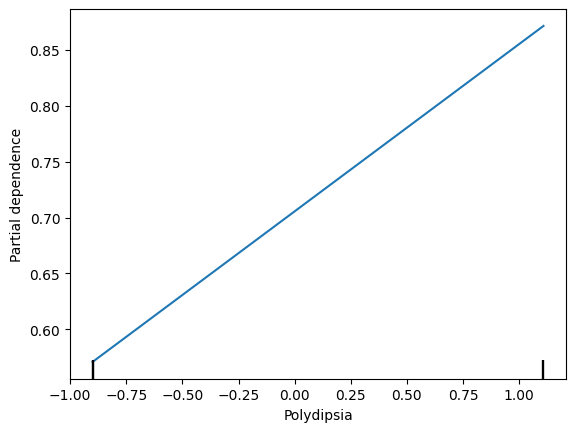

In [ ]:
feature_name = 'Polydipsia'
PartialDependenceDisplay.from_estimator(lr, X_test, [feature_name])
plt.show()

In [ ]:
lr_pred = lr.predict(X_test)
lr_pred
diab_data_pred=pd.merge(X_test,pd.DataFrame(lr_pred,columns=['predicted']),left_index=True,right_index=True)
diab_data_pred.head(10)

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,predicted
86,-0.825320,-1.305775,1.006753,1.108779,1.180520,0.838786,1.091694,-0.535328,1.108779,1.026307,1.766627,1.083269,1.148428,1.289753,-0.723821,-0.450901,1
32,-0.907614,0.764356,-0.991382,-0.900159,-0.845455,0.838786,-0.914246,-0.535328,-0.900159,-0.972493,-0.564962,1.083269,-0.869081,-0.773852,1.378900,-0.450901,1
84,-1.072204,-1.305775,1.006753,1.108779,1.180520,0.838786,1.091694,-0.535328,1.108779,1.026307,-0.564962,1.083269,1.148428,1.289753,-0.723821,-0.450901,1
79,-0.413847,-1.305775,1.006753,1.108779,1.180520,0.838786,1.091694,-0.535328,1.108779,-0.972493,-0.564962,-0.921357,1.148428,1.289753,-0.723821,2.213515,1
53,0.162215,-1.305775,-0.991382,1.108779,1.180520,0.838786,-0.914246,-0.535328,1.108779,-0.972493,-0.564962,1.083269,-0.869081,-0.773852,-0.723821,-0.450901,0
44,-0.660731,-1.305775,1.006753,1.108779,1.180520,0.838786,-0.914246,-0.535328,1.108779,1.026307,-0.564962,-0.921357,1.148428,1.289753,-0.723821,-0.450901,1
100,-0.002374,-1.305775,1.006753,1.108779,1.180520,-1.189906,1.091694,1.864420,-0.900159,-0.972493,1.766627,1.083269,-0.869081,1.289753,1.378900,2.213515,0
87,-1.648266,-1.305775,-0.991382,-0.900159,-0.845455,-1.189906,-0.914246,-0.535328,1.108779,-0.972493,-0.564962,-0.921357,1.148428,1.289753,-0.723821,-0.450901,0
94,-0.989909,-1.305775,1.006753,1.108779,-0.845455,0.838786,1.091694,-0.535328,1.108779,1.026307,-0.564962,1.083269,1.148428,-0.773852,-0.723821,-0.450901,1
28,-0.825320,0.764356,-0.991382,1.108779,-0.845455,-1.189906,-0.914246,1.864420,-0.900159,-0.972493,-0.564962,-0.921357,-0.869081,-0.773852,1.378900,-0.450901,0


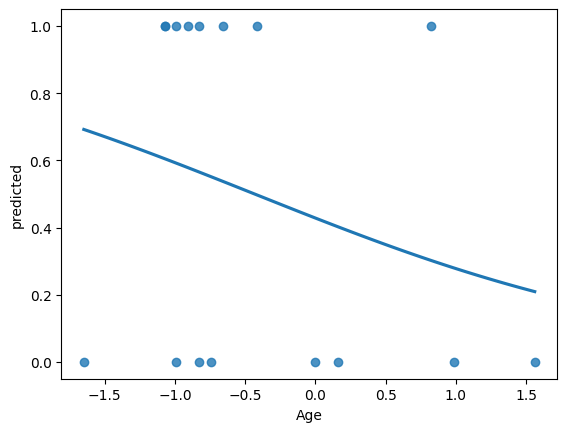

In [ ]:
sns.regplot(x='Age', y = 'predicted', data= diab_data_pred, logistic= True, ci=None);

<span style= "font-size:18px; font-weight:bold;">Probability of Occurence</span>

We will apply predict_proba function to generate the probability values of diabetes outcomes. From the test case below,we understand the difference between outcomes using Predict(1,0)and the predict_proba(the probability of occurence of 1, 0 i.e. 0.99, 0.00)

In [ ]:
lr_proba = lr.predict_proba(X_test[:5])
lr_proba = pd.DataFrame(lr_proba)
lr_proba

,0,1
0,0.000024,0.999976
1,0.091426,0.908574
2,0.995099,0.004901
3,0.943658,0.056342
4,0.944421,0.055579



<span style= "font-size:18px; font-weight:bold;">Confusion Matrix for Logistic Regression</span>

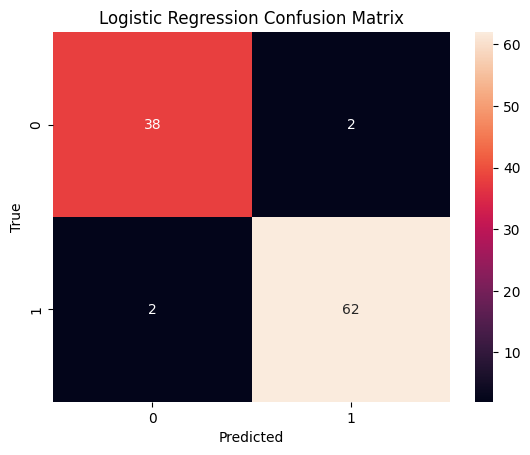

In [ ]:
sns.heatmap(confusion_matrix(y_test, lr_pred), annot= True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

In [ ]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        40
           1       0.97      0.97      0.97        64

    accuracy                           0.96       104
   macro avg       0.96      0.96      0.96       104
weighted avg       0.96      0.96      0.96       104



<span style= "font-size:20px; font-weight:bold;">Random Forest Classifier </span>


In [ ]:
rf = RandomForestClassifier(random_state= 10)
rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

print (f'model score on training data: {rf.score(X_train, y_train)}')
print (f'model score on testing data: {rf.score(X_test, y_test)}')

model score on training data: 1.0
model score on testing data: 0.9903846153846154


In [ ]:
print(len(X_train.columns.tolist()))
len(rf.feature_importances_)

16


16

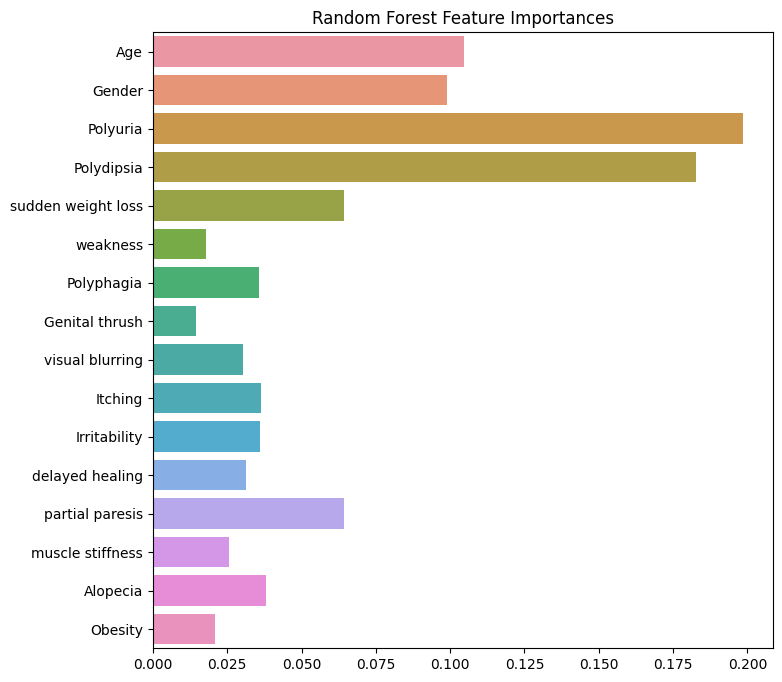

In [ ]:
plt.figure(figsize = (8,8))
sns.barplot(x = rf.feature_importances_, y = X_train.columns.tolist())
plt.title('Random Forest Feature Importances');

<span style= "font-size:20px; font-weight:bold;">Permutation Importance for Random Forest Classifier</span> 

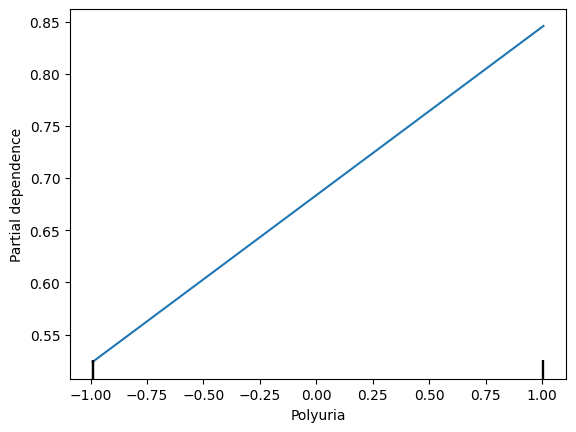

In [ ]:
feature_name = 'Polyuria'
PartialDependenceDisplay.from_estimator(rf, X_test, [feature_name])
plt.show()

In [ ]:
!pip install shap

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 kB 29.9 MB/s eta 0:00:00


In [ ]:
import shap

In [ ]:
row_to_show = 5
data_for_prediction = X_test.iloc[row_to_show]

# Create object that can calculate shap values
explainer = shap.TreeExplainer(rf)

# Calculate Shap values
shap_values = explainer.shap_values(data_for_prediction)

shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[1], X_test.columns)

In [ ]:
diab_data_pred1 = pd.merge(X_test,pd.DataFrame(rf_pred,columns=['predicted']),left_index=True,right_index=True)
diab_data_pred1.head(10)

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,predicted
86,-0.825320,-1.305775,1.006753,1.108779,1.180520,0.838786,1.091694,-0.535328,1.108779,1.026307,1.766627,1.083269,1.148428,1.289753,-0.723821,-0.450901,1
32,-0.907614,0.764356,-0.991382,-0.900159,-0.845455,0.838786,-0.914246,-0.535328,-0.900159,-0.972493,-0.564962,1.083269,-0.869081,-0.773852,1.378900,-0.450901,1
84,-1.072204,-1.305775,1.006753,1.108779,1.180520,0.838786,1.091694,-0.535328,1.108779,1.026307,-0.564962,1.083269,1.148428,1.289753,-0.723821,-0.450901,1
79,-0.413847,-1.305775,1.006753,1.108779,1.180520,0.838786,1.091694,-0.535328,1.108779,-0.972493,-0.564962,-0.921357,1.148428,1.289753,-0.723821,2.213515,1
53,0.162215,-1.305775,-0.991382,1.108779,1.180520,0.838786,-0.914246,-0.535328,1.108779,-0.972493,-0.564962,1.083269,-0.869081,-0.773852,-0.723821,-0.450901,0
44,-0.660731,-1.305775,1.006753,1.108779,1.180520,0.838786,-0.914246,-0.535328,1.108779,1.026307,-0.564962,-0.921357,1.148428,1.289753,-0.723821,-0.450901,1
100,-0.002374,-1.305775,1.006753,1.108779,1.180520,-1.189906,1.091694,1.864420,-0.900159,-0.972493,1.766627,1.083269,-0.869081,1.289753,1.378900,2.213515,0
87,-1.648266,-1.305775,-0.991382,-0.900159,-0.845455,-1.189906,-0.914246,-0.535328,1.108779,-0.972493,-0.564962,-0.921357,1.148428,1.289753,-0.723821,-0.450901,0
94,-0.989909,-1.305775,1.006753,1.108779,-0.845455,0.838786,1.091694,-0.535328,1.108779,1.026307,-0.564962,1.083269,1.148428,-0.773852,-0.723821,-0.450901,1
28,-0.825320,0.764356,-0.991382,1.108779,-0.845455,-1.189906,-0.914246,1.864420,-0.900159,-0.972493,-0.564962,-0.921357,-0.869081,-0.773852,1.378900,-0.450901,0


<span style= "font-size:18px; font-weight:bold;">Confusion Matrix for Random Forest</span>

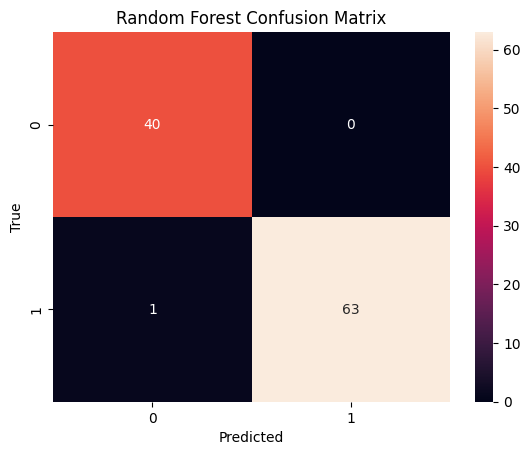

In [ ]:
sns.heatmap(confusion_matrix(y_test, rf_pred), annot= True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Random Forest Confusion Matrix')
plt.show()

In [ ]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        40
           1       1.00      0.98      0.99        64

    accuracy                           0.99       104
   macro avg       0.99      0.99      0.99       104
weighted avg       0.99      0.99      0.99       104



<span style= "font-size:20px; font-weight:bold;">Support Vector Machine</span>


In [ ]:
# Building a Support Vector Machine on train data

svc = SVC(C= .1, kernel='linear', gamma= 1)
svc.fit(X_train, y_train)

svc_pred = svc.predict(X_test)

print (f'model score on training data: {svc.score(X_train, y_train)}')
print (f'model score on testing data: {svc.score(X_test, y_test)}')

model score on training data: 0.9326923076923077
model score on testing data: 0.9230769230769231


In [ ]:
print(len(X_train.columns.tolist()))
len(svc.coef_[0])

16


16

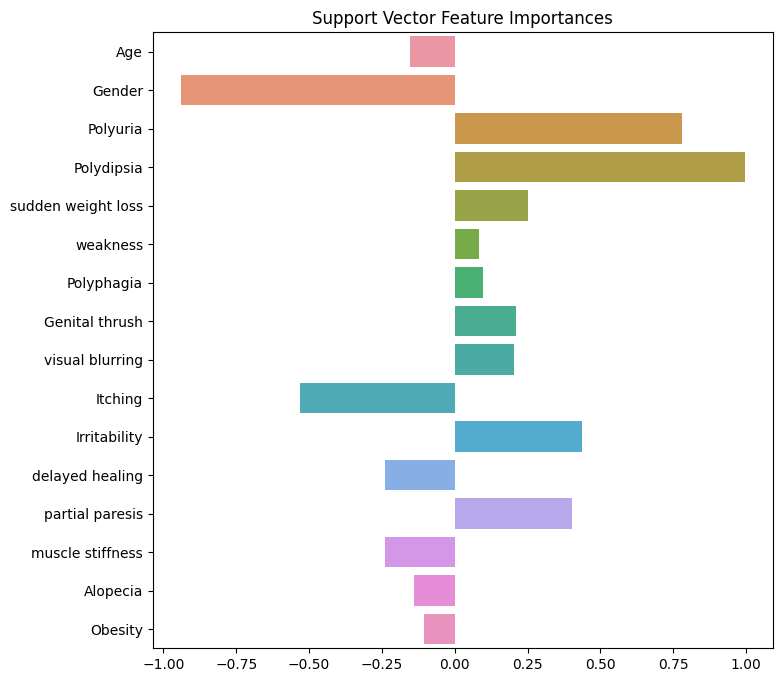

In [ ]:
plt.figure(figsize = (8,8))
sns.barplot(x = svc.coef_[0], y = X_train.columns.tolist())
plt.title ('Support Vector Feature Importances');

In [ ]:
diab_data_pred2=pd.merge(X_test,pd.DataFrame(svc_pred,columns=['predicted']),left_index=True,right_index=True)
diab_data_pred2.head(10)

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,predicted
86,-0.825320,-1.305775,1.006753,1.108779,1.180520,0.838786,1.091694,-0.535328,1.108779,1.026307,1.766627,1.083269,1.148428,1.289753,-0.723821,-0.450901,1
32,-0.907614,0.764356,-0.991382,-0.900159,-0.845455,0.838786,-0.914246,-0.535328,-0.900159,-0.972493,-0.564962,1.083269,-0.869081,-0.773852,1.378900,-0.450901,1
84,-1.072204,-1.305775,1.006753,1.108779,1.180520,0.838786,1.091694,-0.535328,1.108779,1.026307,-0.564962,1.083269,1.148428,1.289753,-0.723821,-0.450901,1
79,-0.413847,-1.305775,1.006753,1.108779,1.180520,0.838786,1.091694,-0.535328,1.108779,-0.972493,-0.564962,-0.921357,1.148428,1.289753,-0.723821,2.213515,1
53,0.162215,-1.305775,-0.991382,1.108779,1.180520,0.838786,-0.914246,-0.535328,1.108779,-0.972493,-0.564962,1.083269,-0.869081,-0.773852,-0.723821,-0.450901,0
44,-0.660731,-1.305775,1.006753,1.108779,1.180520,0.838786,-0.914246,-0.535328,1.108779,1.026307,-0.564962,-0.921357,1.148428,1.289753,-0.723821,-0.450901,1
100,-0.002374,-1.305775,1.006753,1.108779,1.180520,-1.189906,1.091694,1.864420,-0.900159,-0.972493,1.766627,1.083269,-0.869081,1.289753,1.378900,2.213515,0
87,-1.648266,-1.305775,-0.991382,-0.900159,-0.845455,-1.189906,-0.914246,-0.535328,1.108779,-0.972493,-0.564962,-0.921357,1.148428,1.289753,-0.723821,-0.450901,0
94,-0.989909,-1.305775,1.006753,1.108779,-0.845455,0.838786,1.091694,-0.535328,1.108779,1.026307,-0.564962,1.083269,1.148428,-0.773852,-0.723821,-0.450901,1
28,-0.825320,0.764356,-0.991382,1.108779,-0.845455,-1.189906,-0.914246,1.864420,-0.900159,-0.972493,-0.564962,-0.921357,-0.869081,-0.773852,1.378900,-0.450901,0


<span style= "font-size:18px; font-weight:bold;">Confusion Matrix for Support Vector Machine</span>

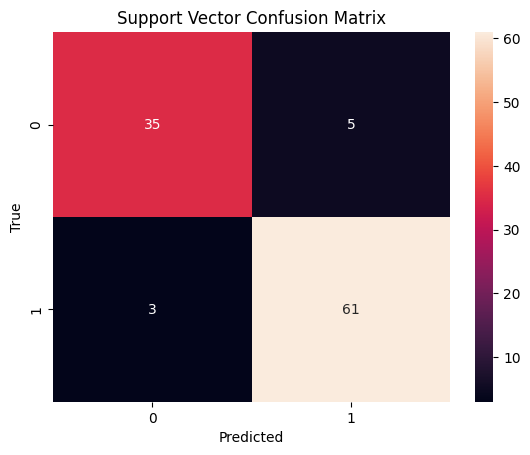

In [ ]:
sns.heatmap(confusion_matrix(y_test, svc_pred), annot= True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Support Vector Confusion Matrix')
plt.show()

In [ ]:
print(classification_report(y_test, svc_pred))

              precision    recall  f1-score   support

           0       0.92      0.88      0.90        40
           1       0.92      0.95      0.94        64

    accuracy                           0.92       104
   macro avg       0.92      0.91      0.92       104
weighted avg       0.92      0.92      0.92       104



<span style= "font-size:20px; font-weight:bold;">Decision Tree Classifier</span>

In [ ]:
dt = DecisionTreeClassifier(max_depth=3, random_state=1234)
dt.fit(X, y)

dt_pred = dt.predict(X_test)

print (f'model score on training data: {dt.score(X_train, y_train)}')
print (f'model score on testing data: {dt.score(X_test, y_test)}')

model score on training data: 0.9086538461538461
model score on testing data: 0.9326923076923077


<span style= "font-size:18px; font-weight:bold;">Confusion Matrix for Decision Tree Classifier</span>

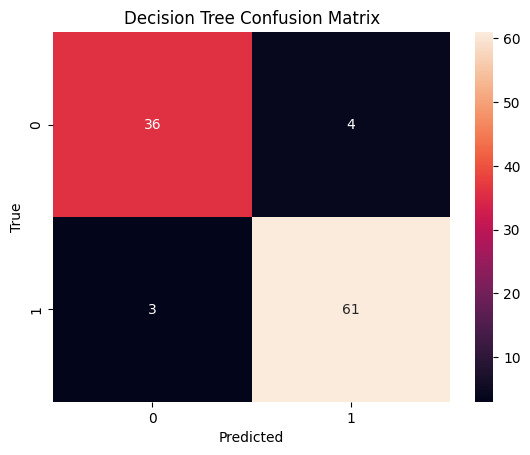

In [ ]:
sns.heatmap(confusion_matrix(y_test, dt_pred), annot= True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Decision Tree Confusion Matrix')
plt.show()

In [ ]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91        40
           1       0.94      0.95      0.95        64

    accuracy                           0.93       104
   macro avg       0.93      0.93      0.93       104
weighted avg       0.93      0.93      0.93       104



<span style= "font-size:18px; font-weight:bold;">Extract Decision Rules </span>

In [ ]:
feature_names = diab_data.drop('class', axis = 1)
class_name = diab_data['class']

def get_rules(tree, feature_names, class_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]

    paths = []
    path = []
    
    def recurse(node, path, paths):
        
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            p1, p2 = list(path), list(path)
            p1 += [f"({name} <= {np.round(threshold, 3)})"]
            recurse(tree_.children_left[node], p1, paths)
            p2 += [f"({name} > {np.round(threshold, 3)})"]
            recurse(tree_.children_right[node], p2, paths)
        else:
            path += [(tree_.value[node], tree_.n_node_samples[node])]
            paths += [path]
            
    recurse(0, path, paths)

    # sort by samples count
    samples_count = [p[-1][1] for p in paths]
    ii = list(np.argsort(samples_count))
    paths = [paths[i] for i in reversed(ii)]
    
    rules = []
    for path in paths:
        rule = "if "
        
        for p in path[:-1]:
            if rule != "if ":
                rule += " and "
            rule += str(p)
        rule += " then "
        if class_names is None:
            rule += "response: "+str(np.round(path[-1][0][0][0],3))
        else:
            classes = path[-1][0][0]
            l = np.argmax(classes)
            rule += f"class: {class_names[l]} (proba: {np.round(100.0*classes[l]/np.sum(classes),2)}%)"
        rule += f" | based on {path[-1][1]:,} samples"
        rules += [rule]
        
    return rules


In [ ]:
rules = get_rules(dt, diab_data.columns, diab_data['class'])
for r in rules:
    print(r)


if (Polyuria > 0.5) and (Age <= 69.5) and (Polydipsia > 0.5) then class: 1 (proba: 100.0%) | based on 191 samples
if (Polyuria <= 0.5) and (Gender > 0.5) and (Polydipsia <= 0.5) then class: 1 (proba: 92.4%) | based on 171 samples
if (Polyuria > 0.5) and (Age <= 69.5) and (Polydipsia <= 0.5) then class: 1 (proba: 85.19%) | based on 54 samples
if (Polyuria <= 0.5) and (Gender <= 0.5) and (Alopecia <= 0.5) then class: 1 (proba: 87.23%) | based on 47 samples
if (Polyuria <= 0.5) and (Gender > 0.5) and (Polydipsia > 0.5) then class: 1 (proba: 71.43%) | based on 28 samples
if (Polyuria <= 0.5) and (Gender <= 0.5) and (Alopecia > 0.5) then class: 1 (proba: 81.25%) | based on 16 samples
if (Polyuria > 0.5) and (Age > 69.5) and (sudden weight loss <= 0.5) then class: 1 (proba: 100.0%) | based on 7 samples
if (Polyuria > 0.5) and (Age > 69.5) and (sudden weight loss > 0.5) then class: 1 (proba: 100.0%) | based on 6 samples


<span style= "font-size:20px; font-weight:bold;">Plot Decision Tree</span>

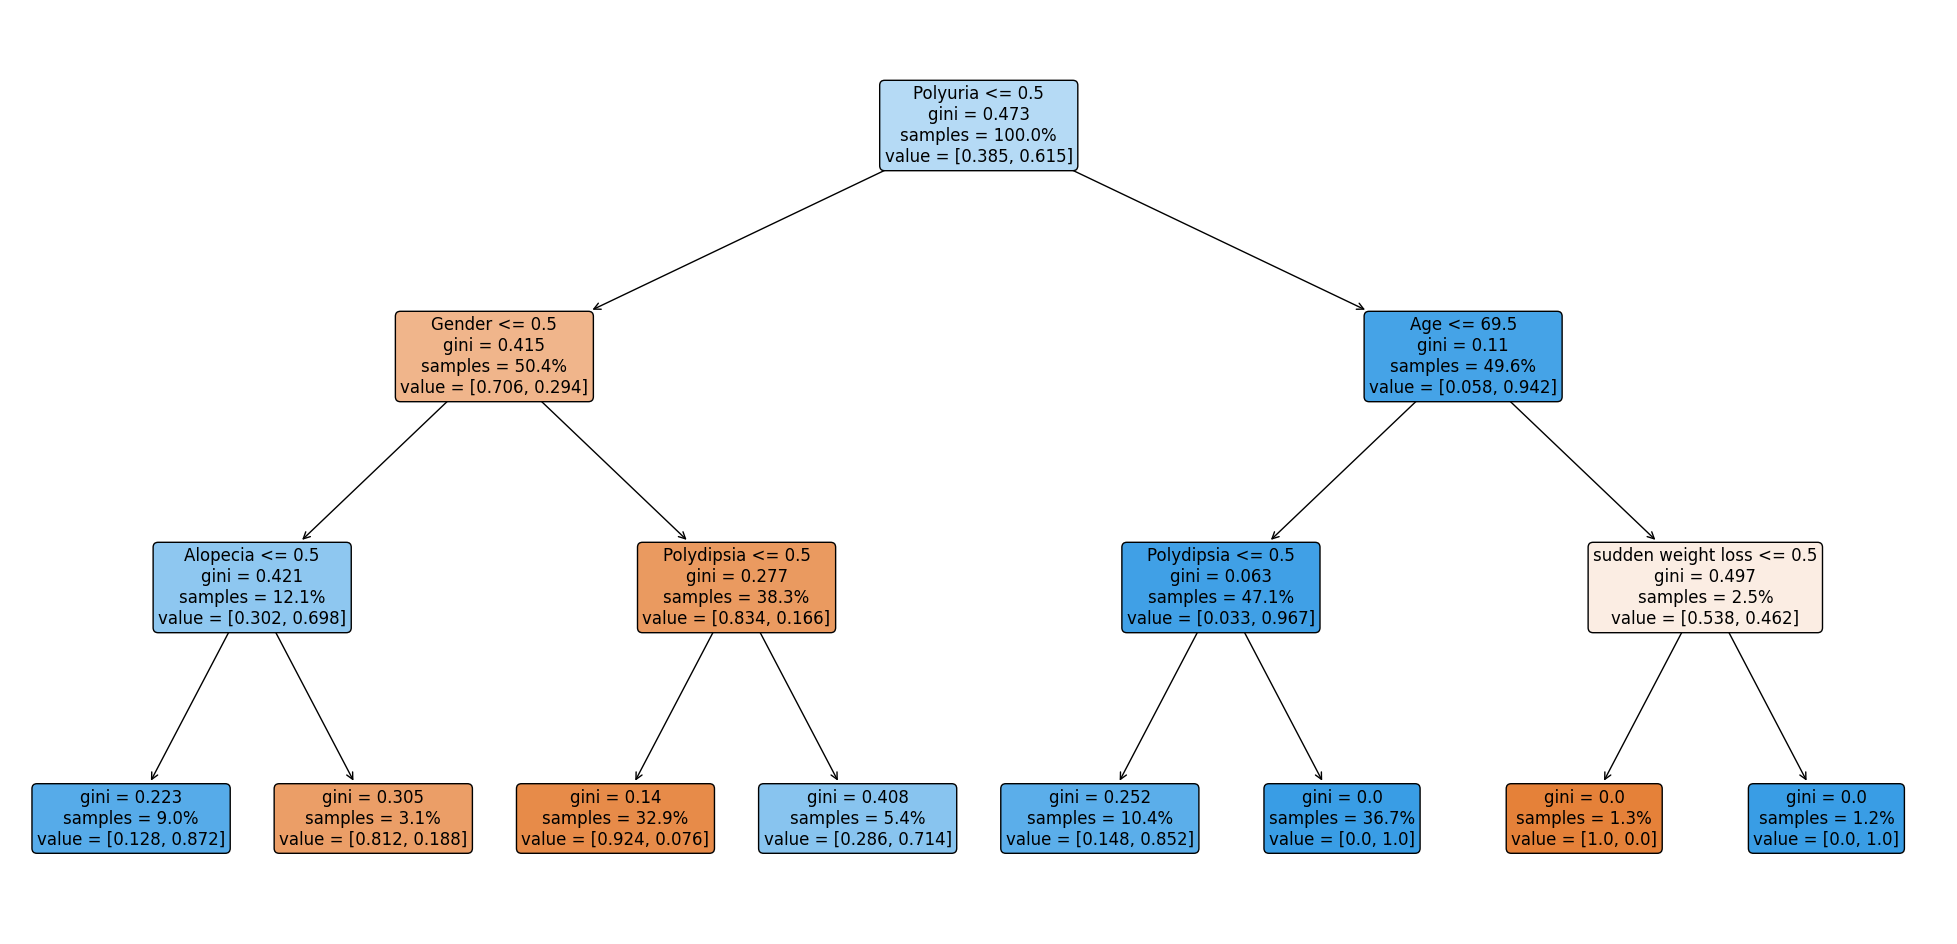

In [ ]:
fig, ax = plt.subplots(figsize=(25,12))
#plot tree
plot_tree(
    decision_tree = dt,
    feature_names = X_train.columns,
    filled = True, #colour leaf with class
    rounded = True, # round leaf edges
    proportion = True, #Display proportion of classes in leaf
    max_depth = 3, # only display first 3 levels
    fontsize = 12, # Enlarge font
    ax=ax, # place in figure axis
);


# **AUC-ROC CURVE**

AUC (Area Under The Curve) ROC (Receiver Operating Characteristics) curve.


Area Under Curve (AUC) =  0.992


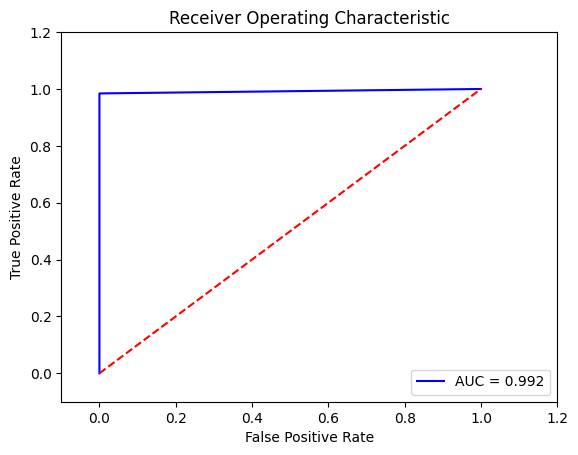

In [ ]:
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, rf_pred)
AreaUnderCurve = round( auc(false_positive_rate, true_positive_rate) ,3)

print('Area Under Curve (AUC) = ',AreaUnderCurve)

plt.title('Receiver Operating Characteristic')

plt.plot(false_positive_rate, true_positive_rate, 'b', label='AUC = %.3f'% AreaUnderCurve)

plt.legend(loc='lower right')

plt.plot([0,1],[0,1],'r--')

plt.xlim([-0.1,1.2])
plt.ylim([-0.1,1.2])

plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

plt.show()

# **PRECISION-RECALL CURVE**

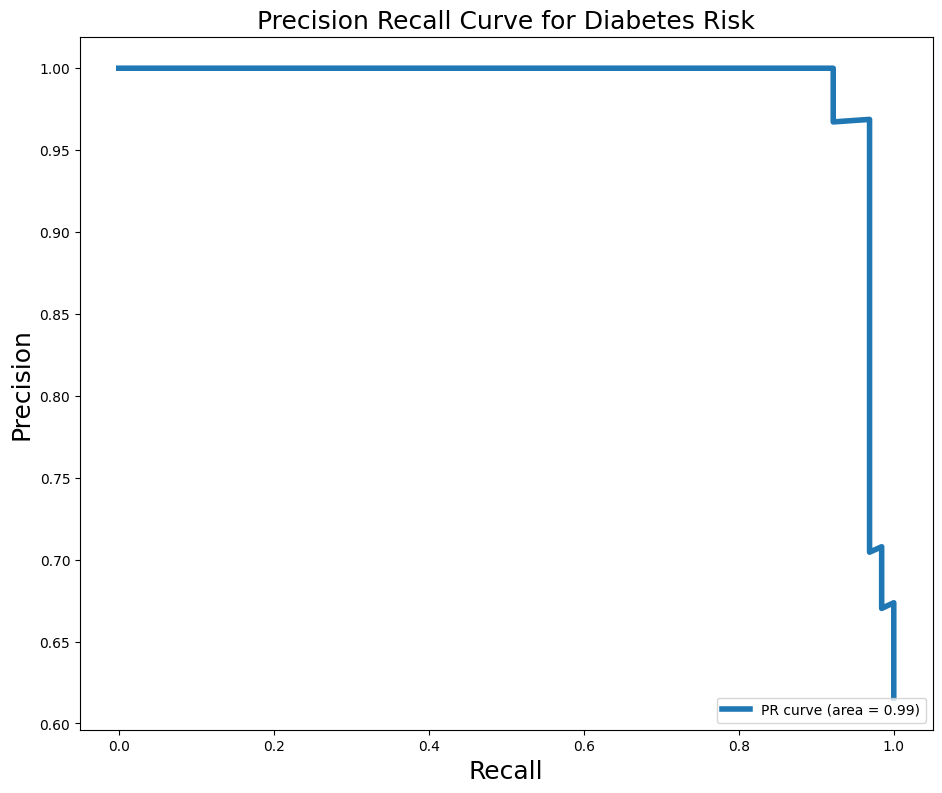

In [ ]:
y_score = lr.decision_function(X_test)

precision, recall, _ = precision_recall_curve(y_test, y_score)
PR_AUC = auc(recall, precision)

plt.figure(figsize=[11,9])
plt.plot(recall, precision, label='PR curve (area = %0.2f)' % PR_AUC, linewidth=4)
plt.xlabel('Recall', fontsize=18)
plt.ylabel('Precision', fontsize=18)
plt.title('Precision Recall Curve for Diabetes Risk', fontsize=18)
plt.legend(loc="lower right")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')